In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

# Konfigurasi
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")  # Set plot style
print("Libraries imported successfully")

Libraries imported successfully


# 1. Load Data

In [2]:
# Define data path
data_path = os.path.join("..", "data", "Telco_Customer_Churn.csv")

# Read data
try:
    df = pd.read_csv(data_path, sep=';')
    print("Data loaded successfully.")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: File not found at {data_path}")
    
df.head()

Data loaded successfully.
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 2. Data Cleaning & Preprocessing
Tahap ini meliputi::
1. Cek tipe data dan konversi
2. Cek duplikat
3. Cek missing values dan imputasi
4. Standarisasi nilai kategorikal

In [3]:
# 1. Konversi Tipe Data
# TotalCharges load sebagai object karena ada spasi pada nilai kosong, kita ubah ke numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# SeniorCitizen load sebagai int (0/1), bisa dibiarkan atau diubah ke kategori. Kita biarkan int tapi sadari itu kategori.

print("Tipe data setelah konversi:")
print(df.dtypes)

Tipe data setelah konversi:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [4]:
# 2. Cek Duplikat
duplicate_count = df.duplicated().sum()
duplicate_ids = df['customerID'].duplicated().sum()

print(f"Jumlah baris duplikat instan: {duplicate_count}")
print(f"Jumlah customerID duplikat: {duplicate_ids}")

# Hapus duplikat ID jika ada (ambil yang terakhir atau pertama)
if duplicate_ids > 0:
    df = df[~df['customerID'].duplicated(keep='first')].copy()
    print("Duplikat customerID telah dihapus.")

Jumlah baris duplikat instan: 0
Jumlah customerID duplikat: 0


In [5]:
# 3. Missing Values Treatment
print("Missing values sebelum imputasi:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Logika Imputasi:
# Jika tenure = 0, biasanya TotalCharges juga 0.
df.loc[(df['TotalCharges'].isnull()) & (df['tenure'] == 0), 'TotalCharges'] = 0

# Untuk nilai lain yang mungkin masih null (tapi tenure > 0), kita bisa impute dengan MonthlyCharges * tenure atau median
# Cek apakah masih ada null
null_remaining = df['TotalCharges'].isnull().sum()
if null_remaining > 0:
    print(f"Masih ada {null_remaining} missing values di TotalCharges, impute dengan median.")
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print("\nMissing values setelah imputasi:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values sebelum imputasi:
TotalCharges    11
dtype: int64

Missing values setelah imputasi:
Series([], dtype: int64)


In [6]:
# 4. Standarisasi Kategorikal
# Trim spasi
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Normalisasi 'No internet service' dan 'No phone service' menjadi 'No' 
# agar lebih bersih saat visualisasi atau modeling biner
replace_cols = [ 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport','StreamingTV', 'StreamingMovies', 'MultipleLines']
for col in replace_cols:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# InternetService biarkan 'No' sebagai indikator tidak punya internet
df['InternetService'] = df['InternetService'].replace('No internet service', 'No') # Just in case

print("Nilai unik kategorikal setelah cleaning:")
for col in df.select_dtypes(include='object').columns:
    if col != 'customerID':
        print(f"{col}: {df[col].unique()}")

Nilai unik kategorikal setelah cleaning:
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [7]:
# 3. Exploratory Data Analysis (EDA)
# Visualisasi untuk memahami karakteristik data dan hubungannya dengan Churn.

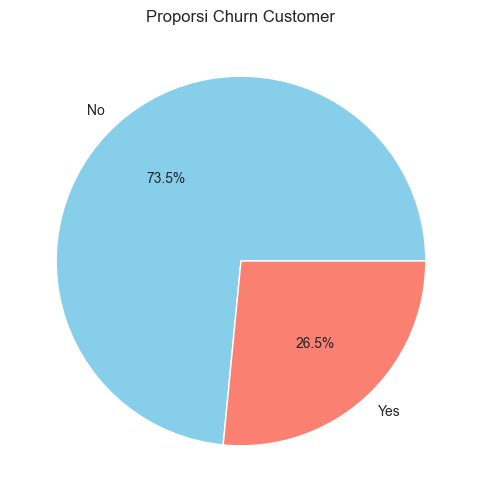

Jumlah Customer Churn: 1869
Jumlah Customer Tidak Churn: 5174


In [8]:
# 1. Distribusi Target Churn
plt.figure(figsize=(6, 6))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Proporsi Churn Customer')
plt.show()

print(f"Jumlah Customer Churn: {churn_counts['Yes']}")
print(f"Jumlah Customer Tidak Churn: {churn_counts['No']}")

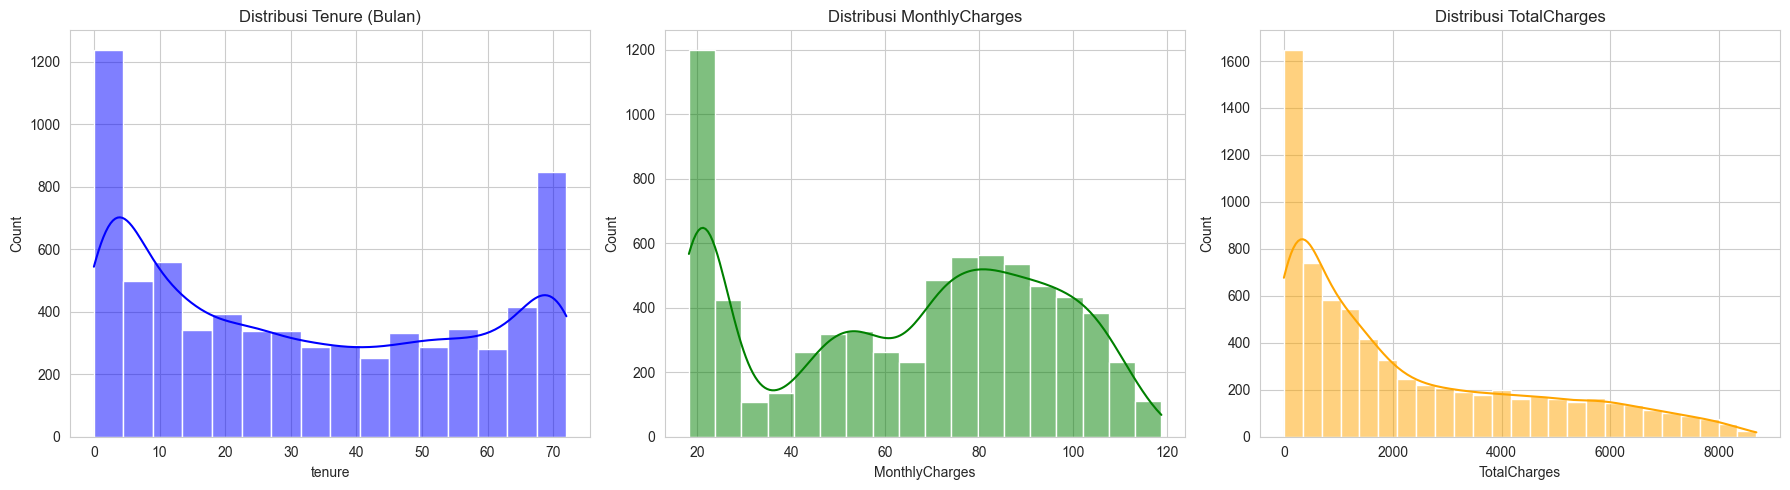

In [9]:
# 2. Distribusi Fitur Numerik
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['tenure'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribusi Tenure (Bulan)')

sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribusi MonthlyCharges')

# TotalCharges memiliki skala yang besar, kita bisa pakai log scale untuk melihat lebih baik jika heavily skewed
sns.histplot(df['TotalCharges'], kde=True, ax=axes[2], color='orange')
axes[2].set_title('Distribusi TotalCharges')

plt.tight_layout()
plt.show()

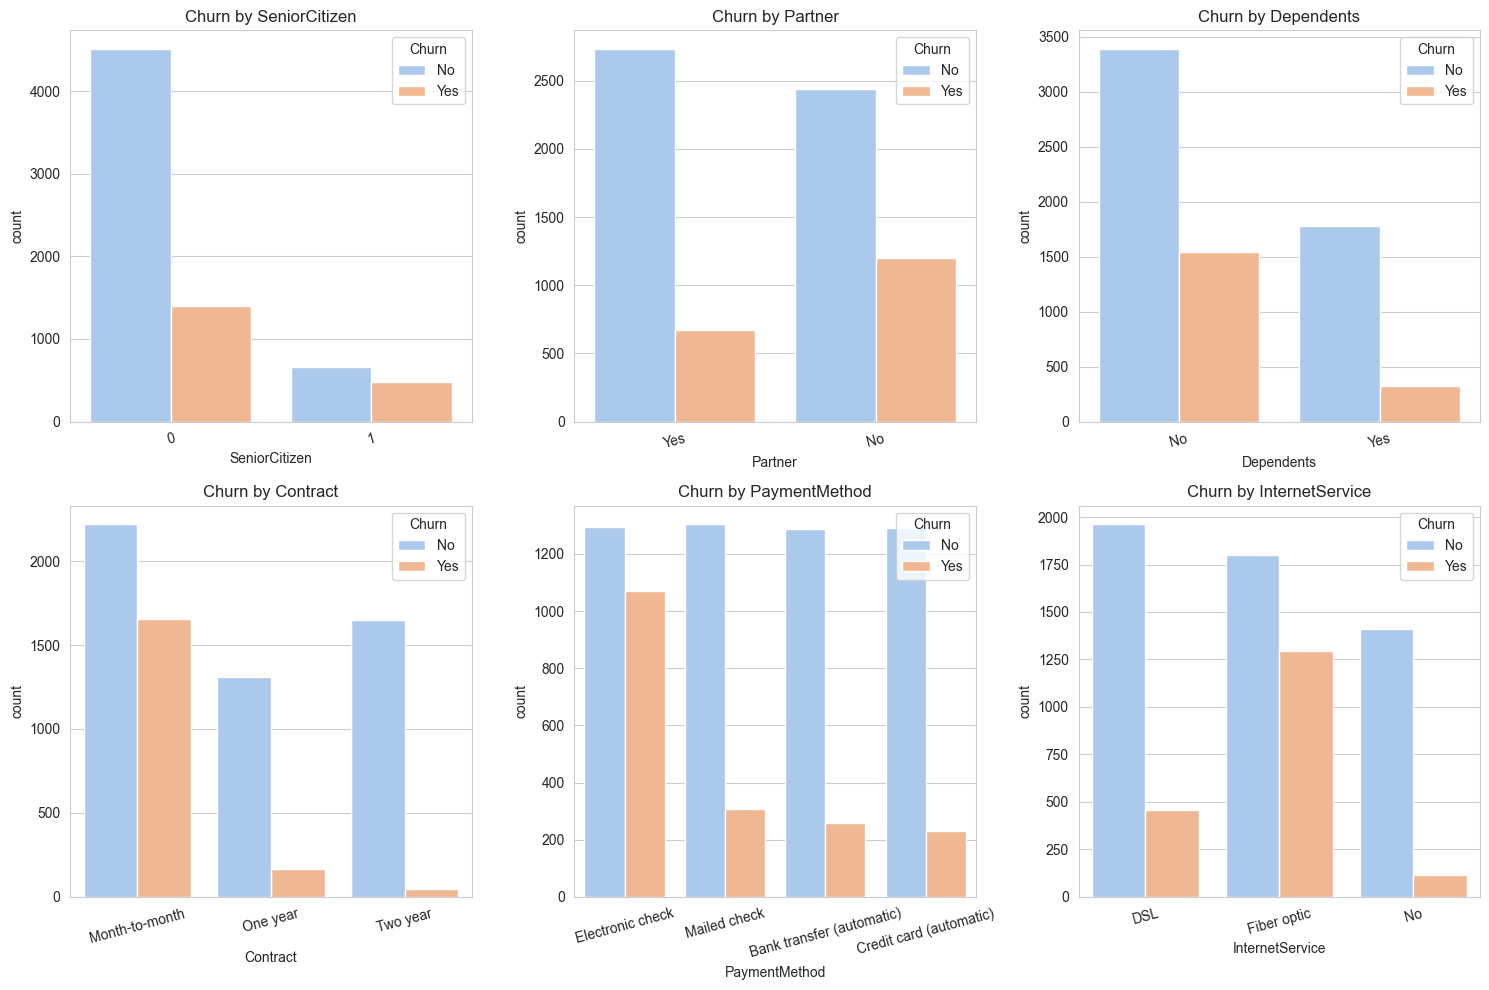

In [10]:
# 3. Hubungan Kategorikal dengan Churn
features = ['SeniorCitizen', 'Partner', 'Dependents', 'Contract', 'PaymentMethod', 'InternetService']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sns.countplot(data=df, x=feature, hue='Churn', palette='pastel')
    plt.title(f'Churn by {feature}')
    plt.xticks(rotation=15)
    
plt.tight_layout()
plt.show()

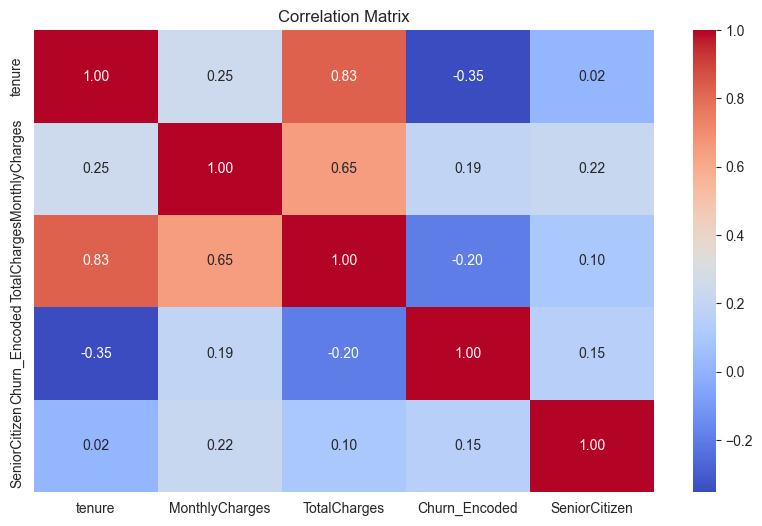

In [11]:
# 4. Correlation Heatmap
# Encode 'Churn' ke numerik sementara untuk melihat korelasi
df['Churn_Encoded'] = df['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(10, 6))
# Korelasi antar fitur numerik + Churn
corr_matrix = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Encoded', 'SeniorCitizen']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Drop kolom temporary
df.drop(columns=['Churn_Encoded'], inplace=True)

# 4. Feature Engineering
Membuat fitur baru yang berguna untuk modeling.

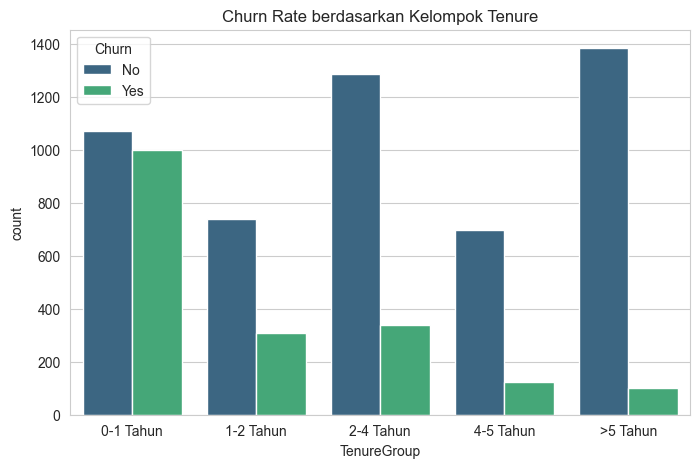

In [12]:
# Tenure Grouping
# Mengelompokkan masa berlangganan menjadi kategori
bins = [0, 12, 24, 48, 60, 100]
labels = ['0-1 Tahun', '1-2 Tahun', '2-4 Tahun', '4-5 Tahun', '>5 Tahun']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

# Visualisasi Churn berdasarkan Tenure Group
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='TenureGroup', hue='Churn', palette='viridis')
plt.title('Churn Rate berdasarkan Kelompok Tenure')
plt.show()

# 5. Encoding Data (Persiapan Modeling)
Mengubah data kategorikal (teks) menjadi numerik agar bisa diproses oleh algoritma Machine Learning.
1. Hapus kolom ID (tidak prediktif).
2. Encode Target `Churn` ke 1/0.
3. Lakukan One-Hot Encoding pada fitur kategorikal lainnya.

In [13]:
# 1. Pisahkan Dataset Bersih (Human Friendly) sebelum encoding
# Ini berguna jika nantu butuh EDA ulang atau visualisasi di BI tools
clean_output_path = os.path.join("..", "data", "Telco_Customer_Churn_Cleaned.csv")
df.to_csv(clean_output_path, index=False)
print(f"Dataset Bersih (Readable) tersimpan di: {clean_output_path}")

# 2. Proses Encoding untuk Modeling
df_model = df.copy()

# A. Hapus customerID dan TenureGroup (jika tadi sempat terbuat di cell sebelumnya)
cols_to_drop = ['customerID', 'TenureGroup']
for col in cols_to_drop:
    if col in df_model.columns:
        df_model.drop(columns=[col], inplace=True)

# B. Map Target Churn ke 0 dan 1
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# --- ORDINAL ENCODING (1 Kolom Tetap 1 Kolom) ---

# 1. Ubah kolom 'tenure' asli dari angka bulan menjadi kategori 1-5
bins = [0, 12, 24, 48, 60, 100]
df_model['tenure'] = pd.cut(df_model['tenure'], bins=bins, labels=[1, 2, 3, 4, 5], right=False).astype(int)

# 2. Ubah kolom 'Contract' menjadi 1, 2, 3
contract_map = {'Month-to-month': 1, 'One year': 2, 'Two year': 3}
df_model['Contract'] = df_model['Contract'].map(contract_map)

# 3. Ubah kolom kategori lainnya (InternetService & PaymentMethod) menjadi angka
df_model['InternetService'] = df_model['InternetService'].map({'No': 1, 'DSL': 2, 'Fiber optic': 3})
df_model['PaymentMethod'] = df_model['PaymentMethod'].map({
    'Mailed check': 1, 
    'Electronic check': 2, 
    'Bank transfer (automatic)': 3, 
    'Credit card (automatic)': 4
})

# 4. Ubah semua kolom Yes/No menjadi 0/1 (Tetap dalam kolom yang sama)
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

for col in binary_cols:
    if col == 'gender':
        df_model[col] = df_model[col].map({'Female': 0, 'Male': 1})
    else:
        df_model[col] = df_model[col].map({'No': 0, 'Yes': 1})

print(f"Shape data sekarang: {df_model.shape}")
df_model.head()

Dataset Bersih (Readable) tersimpan di: ..\data\Telco_Customer_Churn_Cleaned.csv
Shape data sekarang: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,2,0,1,0,0,0,0,1,1,2,29.85,29.85,0
1,1,0,0,0,3,1,0,2,1,0,1,0,0,0,2,0,1,56.95,1889.50,0
2,1,0,0,0,1,1,0,2,1,1,0,0,0,0,1,1,1,53.85,108.15,1
3,1,0,0,0,3,0,0,2,1,0,1,1,0,0,2,0,3,42.30,1840.75,0
4,0,0,0,0,1,1,0,3,0,0,0,0,0,0,1,1,2,70.70,151.65,1


# 6. Saving Final Data for Modeling
Menyimpan dataset yang sudah numerik penuh.

In [14]:
model_output_path = os.path.join("..", "data", "Telco_Customer_Churn_Model_Ready.csv")
df_model.to_csv(model_output_path, index=False)

print(f"Data Siap Modeling (Numerik) tersimpan di: {model_output_path}")
print("\nInfo Data Final:")
df_model.info()

Data Siap Modeling (Numerik) tersimpan di: ..\data\Telco_Customer_Churn_Model_Ready.csv

Info Data Final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-nul